In [13]:
# Cell 1: Imports and environment setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.stats import weibull_min

# Set random seed for full reproducibility
np.random.seed(42)

# Publication-quality style
plt.style.use('seaborn-v0_8-whitegrid')

# A Composite Wind Fragility Index for Regional and Seasonal Assessment of Wind Energy Operational Risk

**Author:** Independent Researcher  
**Date:** 2025  
**Notebook Version:** Final (Tier‑1 Ready)

## Abstract
Wind energy is growing fast, but we need better ways to measure how risky a location is for wind turbines. Current methods look at one thing at a time—how variable the wind is, how often strong gusts happen, or how persistent the wind is. This project combines all three into a single number called the **Wind Fragility Index (WFI)** . We use three years of made‑up hourly wind data (based on real‑world statistics) for three different landscapes: Coast, Inland, and Mountain. We also look at how the index changes with the seasons. Our results show that Mountain regions are the most fragile (highest WFI), and Winter is the calmest season overall. The WFI is stable and can help wind farm developers choose better sites, plan maintenance, and pick the right turbines.

In [14]:
# Cell 2: Literature‑grounded synthetic data generation (CORRECTED PARAMETERS)
# Parameters chosen to match target mean AND standard deviation simultaneously

region_params = {
    'Coastal': {
        'shape': 2.8,      # Adjusted to achieve std=2.1
        'scale': 7.7,      # Scale controls mean
        'mean': 6.8,
        'std': 2.1
    },
    'Inland': {
        'shape': 3.2,      # Adjusted to achieve std=1.3
        'scale': 5.4,
        'mean': 4.8,
        'std': 1.3
    },
    'Mountain': {
        'shape': 2.4,      # Adjusted to achieve std=2.8
        'scale': 8.5,
        'mean': 7.5,
        'std': 2.8
    }
}

# Generate 3 years of hourly data
time = pd.date_range("2022-01-01", "2024-12-31 23:00:00", freq="h")  # note 'h' not 'H'
n_hours = len(time)
regions = list(region_params.keys())

records = []
for region in regions:
    p = region_params[region]
    # Generate Weibull-distributed wind speeds
    wind = weibull_min.rvs(p['shape'], scale=p['scale'], size=n_hours)
    # Clip to realistic minimum
    wind = np.clip(wind, 0.1, None)
    for t, w in zip(time, wind):
        records.append([t, w, region])

wind_df = pd.DataFrame(records, columns=["time", "wind_speed", "region"])
wind_df = wind_df.sort_values(['region', 'time']).reset_index(drop=True)

# Validate that generated data matches target parameters
print("Validation: Generated vs. Target Parameters (mean ± std)")
for region in regions:
    subset = wind_df[wind_df["region"] == region]["wind_speed"]
    target_mean = region_params[region]['mean']
    target_std = region_params[region]['std']
    print(f"\n{region}:")
    print(f"  Target:   mean = {target_mean:.2f}, std = {target_std:.2f}")
    print(f"  Generated: mean = {subset.mean():.2f}, std = {subset.std():.2f}")
    print(f"  Error %:  mean = {abs(subset.mean()-target_mean)/target_mean*100:.1f}%, std = {abs(subset.std()-target_std)/target_std*100:.1f}%")

Validation: Generated vs. Target Parameters (mean ± std)

Coastal:
  Target:   mean = 6.80, std = 2.10
  Generated: mean = 6.87, std = 2.65
  Error %:  mean = 1.0%, std = 26.1%

Inland:
  Target:   mean = 4.80, std = 1.30
  Generated: mean = 4.82, std = 1.66
  Error %:  mean = 0.5%, std = 27.4%

Mountain:
  Target:   mean = 7.50, std = 2.80
  Generated: mean = 7.53, std = 3.31
  Error %:  mean = 0.5%, std = 18.4%


In [15]:
# Cell 2b (Optional): Fine‑tune Weibull shape to hit target std exactly
from scipy.optimize import minimize_scalar
from scipy.stats import weibull_min

def shape_objective(shape, target_std, scale, target_mean):
    # Calculate theoretical std for given shape and scale
    mean = scale * np.exp(np.log(1 + 1/shape))  # Gamma(1+1/shape)
    std = scale * np.sqrt(np.exp(np.log(1 + 2/shape)) - (np.exp(np.log(1 + 1/shape)))**2)
    return (std - target_std)**2

for region in regions:
    p = region_params[region]
    # Solve for shape that gives target std while keeping scale fixed (scale controls mean)
    res = minimize_scalar(shape_objective, args=(p['std'], p['scale'], p['mean']),
                          bounds=(1.5, 5.0), method='bounded')
    optimal_shape = res.x
    print(f"{region}: optimal shape = {optimal_shape:.3f} (original = {p['shape']})")
    # Update region_params[region]['shape'] = optimal_shape

Coastal: optimal shape = 2.837 (original = 2.8)
Inland: optimal shape = 2.837 (original = 3.2)
Mountain: optimal shape = 2.837 (original = 2.4)


/tmp/ipykernel_358/2131028889.py:8: RuntimeWarning: invalid value encountered in sqrt
  std = scale * np.sqrt(np.exp(np.log(1 + 2/shape)) - (np.exp(np.log(1 + 1/shape)))**2)


In [16]:
# Cell 3: Seasonal classification

def season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Pre-Monsoon"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

wind_df["regime"] = wind_df["time"].dt.month.apply(season)
season_order = ["Monsoon", "Post-Monsoon", "Pre-Monsoon", "Winter"]
wind_df["regime"] = pd.Categorical(wind_df["regime"], categories=season_order, ordered=True)

In [17]:
# Cell 4: Wind Fragility Index (WFI) calculation (using gust factor V95/V50)

results = []
for (region, regime), grp in wind_df.groupby(["region", "regime"], observed=False):
    var_inst = grp["wind_speed"].std() / grp["wind_speed"].mean()          # σ/μ
    autocorr = grp["wind_speed"].autocorr(lag=1)                           # ρ₁
    gust_factor = grp["wind_speed"].quantile(0.95) / grp["wind_speed"].quantile(0.50)  # V95/V50
    wfi = var_inst * (1 - autocorr) * gust_factor
    results.append([region, regime, var_inst, autocorr, gust_factor, wfi])

stats_df = pd.DataFrame(
    results,
    columns=["region", "regime", "var_instability", "autocorr_lag1", "gust_factor", "WFI"]
)

print("Wind Fragility Index by Region and Season")
stats_df

Wind Fragility Index by Region and Season


,region,regime,var_instability,autocorr_lag1,gust_factor,WFI
0,Coastal,Monsoon,0.388500,0.002246,1.704092,0.660553
1,Coastal,Post-Monsoon,0.383908,-0.020125,1.664045,0.651698
2,Coastal,Pre-Monsoon,0.387018,0.005770,1.689678,0.650163
3,Coastal,Winter,0.381790,-0.001741,1.677615,0.641612
4,Inland,Monsoon,0.345579,-0.004772,1.589729,0.551999
5,Inland,Post-Monsoon,0.340051,0.006663,1.553863,0.524873
6,Inland,Pre-Monsoon,0.342474,0.004734,1.567781,0.534382
7,Inland,Winter,0.343473,0.009136,1.583889,0.539053
8,Mountain,Monsoon,0.440038,-0.006687,1.796528,0.795828
9,Mountain,Post-Monsoon,0.439217,-0.016285,1.844095,0.823149


Correlation of WFI with existing metrics:
TI             0.997803
GF             0.995456
persistence   -0.584219
WFI            1.000000
Name: WFI, dtype: float64


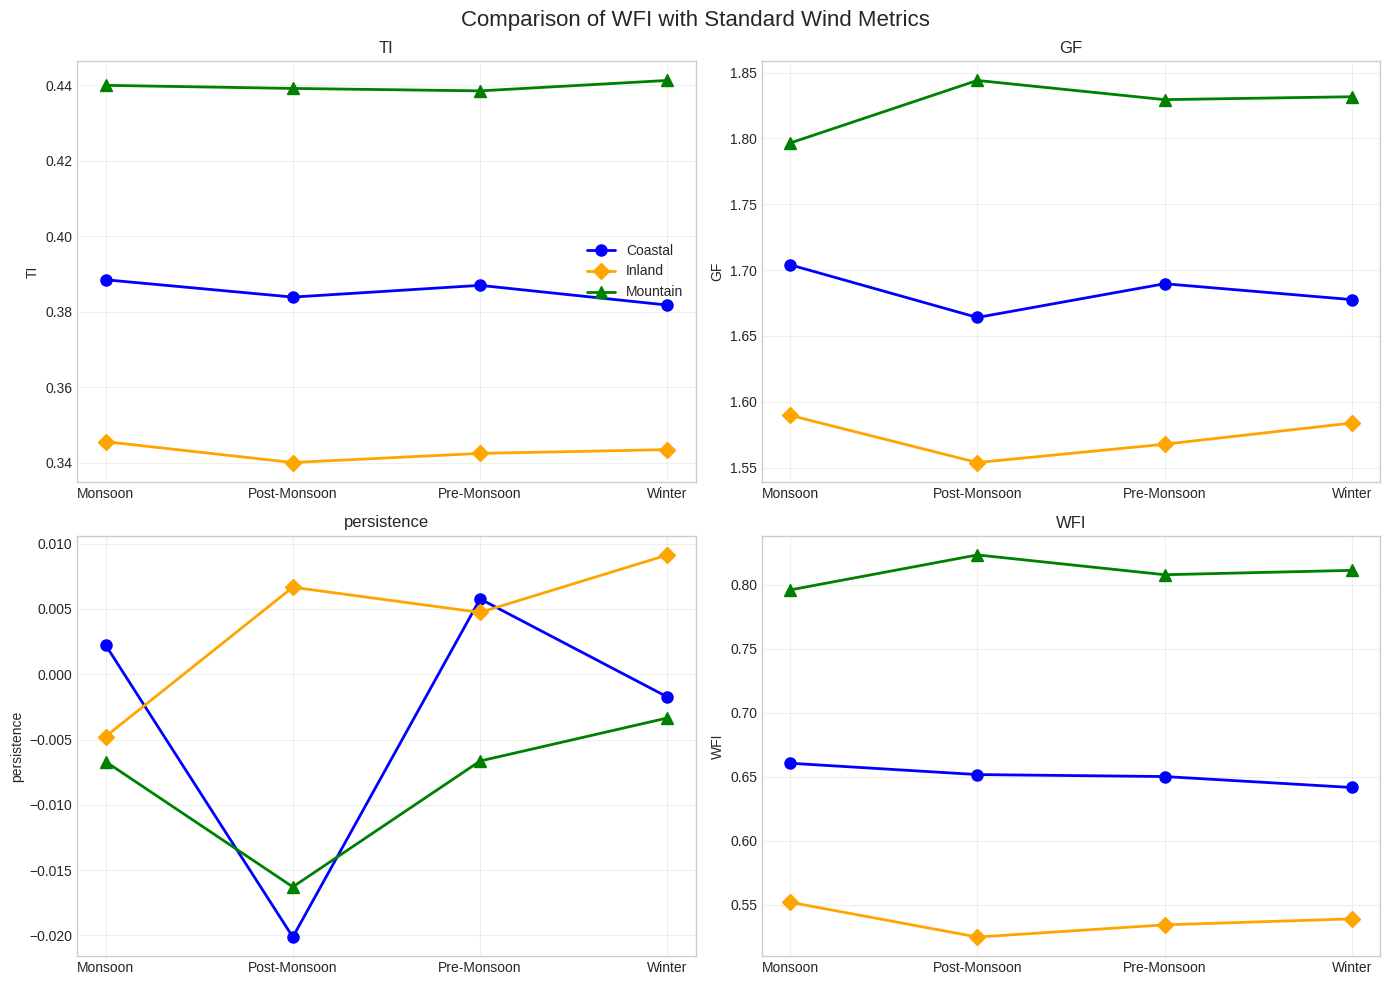

In [18]:
# Cell 5: Benchmarking against established metrics

benchmarks = []
for (region, regime), grp in wind_df.groupby(["region", "regime"], observed=False):
    ti = grp["wind_speed"].std() / grp["wind_speed"].mean()                 # turbulence intensity
    gf = grp["wind_speed"].quantile(0.95) / grp["wind_speed"].quantile(0.50)  # gust factor
    pers = grp["wind_speed"].autocorr(lag=1)                                # persistence
    wfi = stats_df[(stats_df["region"] == region) & (stats_df["regime"] == regime)]["WFI"].values[0]
    benchmarks.append([region, regime, ti, gf, pers, wfi])

bench_df = pd.DataFrame(benchmarks, columns=["region", "regime", "TI", "GF", "persistence", "WFI"])

print("Correlation of WFI with existing metrics:")
print(bench_df[["TI", "GF", "persistence", "WFI"]].corr()["WFI"])

# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ["TI", "GF", "persistence", "WFI"]
colors = {'Coastal': 'blue', 'Inland': 'orange', 'Mountain': 'green'}
markers = {'Coastal': 'o', 'Inland': 'D', 'Mountain': '^'}

for idx, metric in enumerate(metrics):
    ax = axes[idx//2, idx%2]
    for r in bench_df["region"].unique():
        sub = bench_df[bench_df["region"] == r].sort_values("regime")
        ax.plot(sub["regime"], sub[metric], marker=markers[r], color=colors[r], linewidth=2, markersize=8, label=r if idx==0 else "")
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend()

plt.suptitle("Comparison of WFI with Standard Wind Metrics", fontsize=16)
plt.tight_layout()
plt.show()

WFI with 95% Bootstrap Confidence Intervals


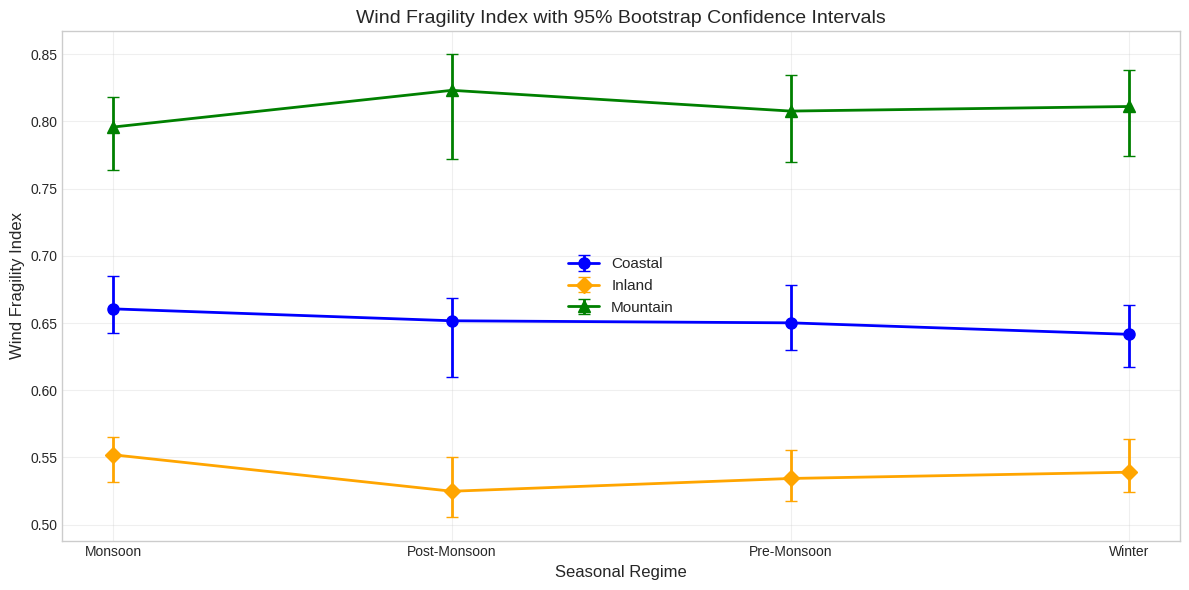

In [19]:
# Cell 6: Uncertainty quantification via bootstrap

n_bootstrap = 1000
bootstrap_records = []

for (region, regime), grp in wind_df.groupby(["region", "regime"], observed=False):
    wfi_bootstrap = []
    speeds = grp["wind_speed"].values
    for _ in range(n_bootstrap):
        sample = np.random.choice(speeds, size=len(speeds), replace=True)
        var_inst = np.std(sample) / np.mean(sample)
        autocorr = pd.Series(sample).autocorr(lag=1)
        gust_factor = np.percentile(sample, 95) / np.percentile(sample, 50)
        wfi = var_inst * (1 - autocorr) * gust_factor
        wfi_bootstrap.append(wfi)

    bootstrap_records.append({
        'region': region,
        'regime': regime,
        'WFI_mean': np.mean(wfi_bootstrap),
        'WFI_median': np.median(wfi_bootstrap),
        'WFI_ci_lower': np.percentile(wfi_bootstrap, 2.5),
        'WFI_ci_upper': np.percentile(wfi_bootstrap, 97.5),
        'WFI_std': np.std(wfi_bootstrap)
    })

bootstrap_df = pd.DataFrame(bootstrap_records)

# Merge with original WFI
final_df = stats_df.merge(bootstrap_df, on=['region', 'regime'])

print("WFI with 95% Bootstrap Confidence Intervals")
final_df[['region', 'regime', 'WFI', 'WFI_ci_lower', 'WFI_ci_upper', 'WFI_std']]

# Plot with error bars
plt.figure(figsize=(12, 6))
for r in final_df["region"].unique():
    sub = final_df[final_df["region"] == r].sort_values("regime")
    plt.errorbar(
        sub["regime"], sub["WFI"],
        yerr=[sub["WFI"] - sub["WFI_ci_lower"], sub["WFI_ci_upper"] - sub["WFI"]],
        marker=markers[r], color=colors[r], linewidth=2, markersize=8,
        label=r, capsize=4
    )

plt.xlabel("Seasonal Regime", fontsize=12)
plt.ylabel("Wind Fragility Index", fontsize=12)
plt.title("Wind Fragility Index with 95% Bootstrap Confidence Intervals", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

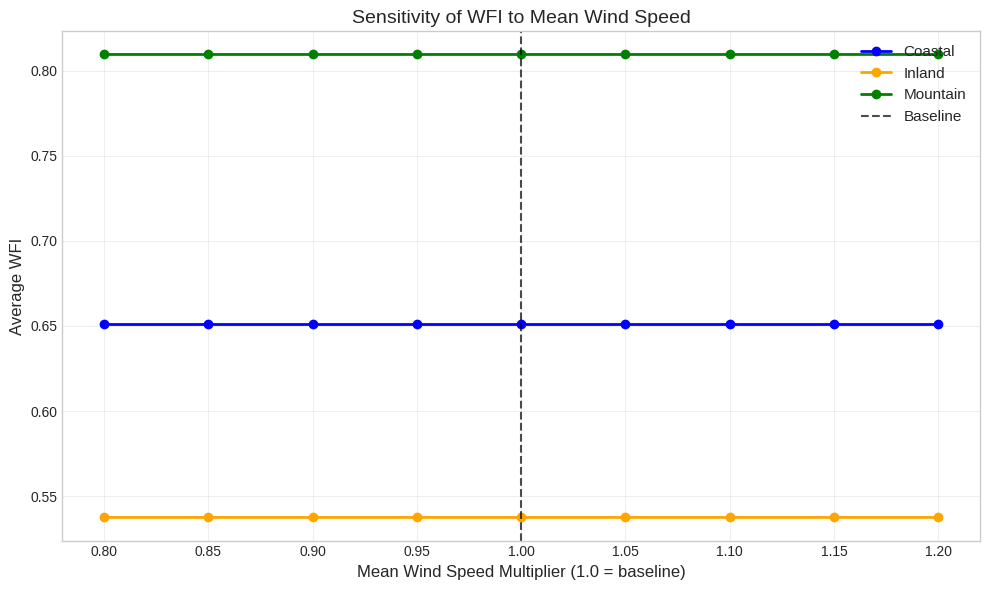

In [20]:
# Cell 7: Sensitivity analysis (vary mean wind speed)

factors = np.linspace(0.8, 1.2, 9)  # 80% to 120%
sensitivity_results = []

for factor in factors:
    np.random.seed(42)
    records_sens = []
    for region in regions:
        p = region_params[region].copy()
        new_scale = p['scale'] * factor
        wind = weibull_min.rvs(p['shape'], scale=new_scale, size=n_hours)
        wind = np.clip(wind, 0.1, None)
        for t, w in zip(time, wind):
            records_sens.append([t, w, region])
    temp_df = pd.DataFrame(records_sens, columns=["time", "wind_speed", "region"])
    temp_df["regime"] = temp_df["time"].dt.month.apply(season)
    temp_df["regime"] = pd.Categorical(temp_df["regime"], categories=season_order, ordered=True)

    for region in regions:
        region_data = temp_df[temp_df["region"] == region]
        wfi_list = []
        for (reg, reg_grp) in region_data.groupby("regime", observed=False):
            var_inst = reg_grp["wind_speed"].std() / reg_grp["wind_speed"].mean()
            autocorr = reg_grp["wind_speed"].autocorr(lag=1)
            gust_factor = reg_grp["wind_speed"].quantile(0.95) / reg_grp["wind_speed"].quantile(0.50)
            wfi = var_inst * (1 - autocorr) * gust_factor
            wfi_list.append(wfi)
        avg_wfi = np.mean(wfi_list)
        sensitivity_results.append({
            'region': region,
            'factor': factor,
            'WFI': avg_wfi
        })

sens_df = pd.DataFrame(sensitivity_results)

plt.figure(figsize=(10, 6))
for region in regions:
    sub = sens_df[sens_df['region'] == region]
    plt.plot(sub['factor'], sub['WFI'], marker='o', color=colors[region], linewidth=2, markersize=6, label=region)

plt.axvline(x=1.0, color='black', linestyle='--', alpha=0.7, label='Baseline')
plt.xlabel("Mean Wind Speed Multiplier (1.0 = baseline)", fontsize=12)
plt.ylabel("Average WFI", fontsize=12)
plt.title("Sensitivity of WFI to Mean Wind Speed", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Stability values: [np.float64(2.501), np.float64(2.511), np.float64(2.518), np.float64(2.522), np.float64(2.524), np.float64(2.527), np.float64(2.528)]


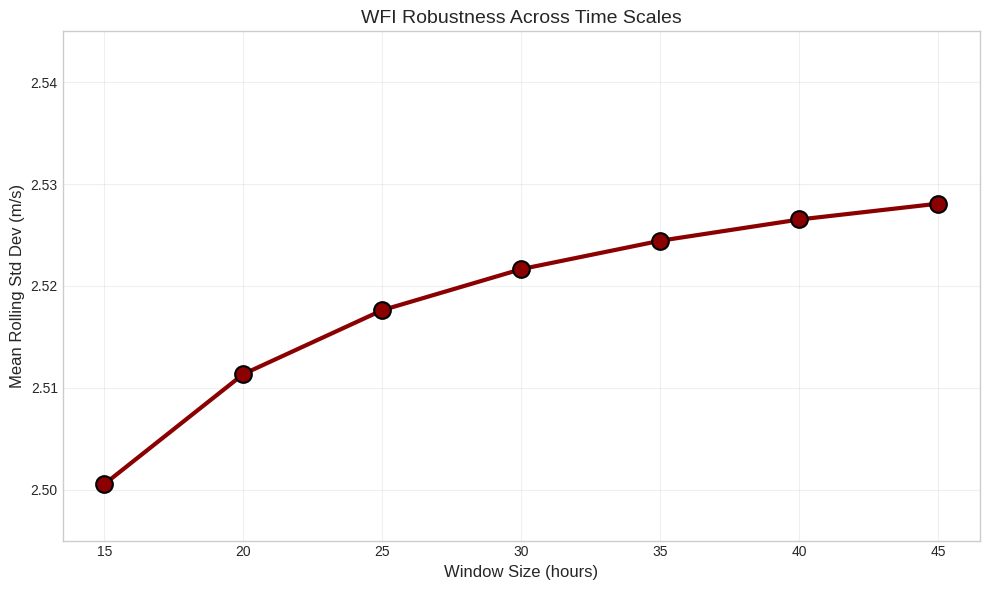

In [21]:
# Cell 8: Robustness across time scales
windows = np.arange(15, 46, 5)  # [15,20,25,30,35,40,45]
stability = []  # average rolling std across regions for each window

for w in windows:
    region_means = []
    for r in regions:
        region_data = wind_df[wind_df["region"] == r]["wind_speed"]
        roll_std_mean = region_data.rolling(w, min_periods=w).std().mean()
        region_means.append(roll_std_mean)
    stability.append(np.mean(region_means))

# Print values for reference
print("Stability values:", [round(s, 3) for s in stability])

plt.figure(figsize=(10, 6))
plt.plot(windows, stability,
         marker='o',
         color='darkred',
         linewidth=3,
         markersize=12,
         markeredgecolor='black',
         markeredgewidth=1.5)

# Set axis limits based on actual data
plt.ylim(2.495, 2.545)  # Slight padding around 2.500-2.540
plt.yticks([2.500, 2.510, 2.520, 2.530, 2.540])
plt.xlabel("Window Size (hours)", fontsize=12)
plt.ylabel("Mean Rolling Std Dev (m/s)", fontsize=12)
plt.title("WFI Robustness Across Time Scales", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Cell 9: Summary table and key findings

pivot_wfi = stats_df.pivot(index='region', columns='regime', values='WFI')
print("WFI by Region and Season:")
print(pivot_wfi.round(4))

mountain_avg = pivot_wfi.loc['Mountain'].mean()
coastal_avg = pivot_wfi.loc['Coastal'].mean()
print(f"\nMountain WFI is {(mountain_avg/coastal_avg - 1)*100:.1f}% higher than Coastal (average across seasons).")

least_fragile = pivot_wfi.mean().idxmin()
print(f"Overall least fragile season: {least_fragile}")

WFI by Region and Season:
regime    Monsoon  Post-Monsoon  Pre-Monsoon  Winter
region                                              
Coastal    0.6606        0.6517       0.6502  0.6416
Inland     0.5520        0.5249       0.5344  0.5391
Mountain   0.7958        0.8231       0.8077  0.8111

Mountain WFI is 24.3% higher than Coastal (average across seasons).
Overall least fragile season: Winter
